In [16]:
!pip install tensorflow tensorflow-hub matplotlib

In [3]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()

Saving style.jpg to style (1).jpg
Saving content.jpg to content (1).jpg


In [14]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (256, 256))
    img = img[tf.newaxis, :]
    return img

content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

In [15]:
hub_model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

In [17]:
stylized_image = hub_model(content_image, style_image)[0]

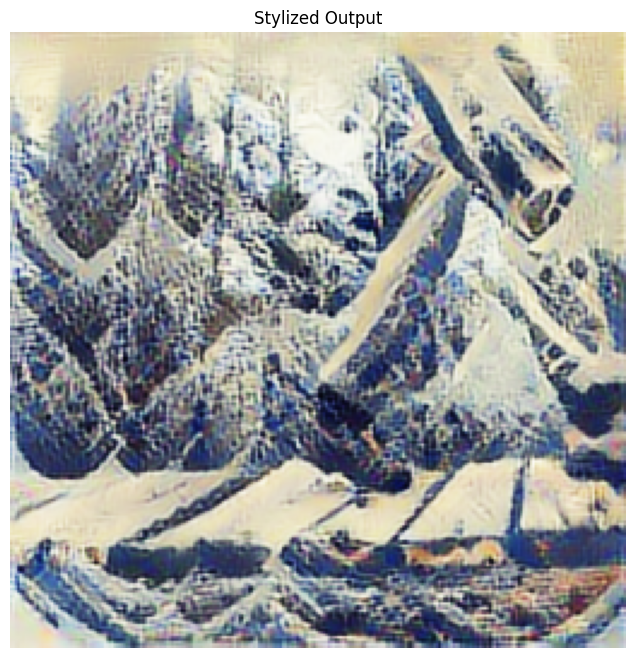

In [18]:
plt.figure(figsize=(8, 8))
plt.imshow(stylized_image[0])
plt.axis("off")
plt.title("Stylized Output")
plt.show()